# Neural LinUCB `loss: avg` 绘图 Notebook

这个 notebook 会解析当前 run 目录下的 `neural_linucb.log`，提取 `TRAIN | module=representation` 对应的 `loss: avg`，并输出一张 PNG 曲线图。

当前版本只绘制原始 `loss avg` 曲线，不做 rolling mean。

默认输出文件：`loss_avg_curve.png`


共解析到 140 个 loss 点
首个点: t=100, avg_loss=0.310681
最后点: t=14000, avg_loss=0.000601
PNG 已保存到: /mnt/d/Study/3/neural-solver-selection/2cmab2/outputs/2026-03-25-18-53-19_neural_linucb/loss_avg_curve.png


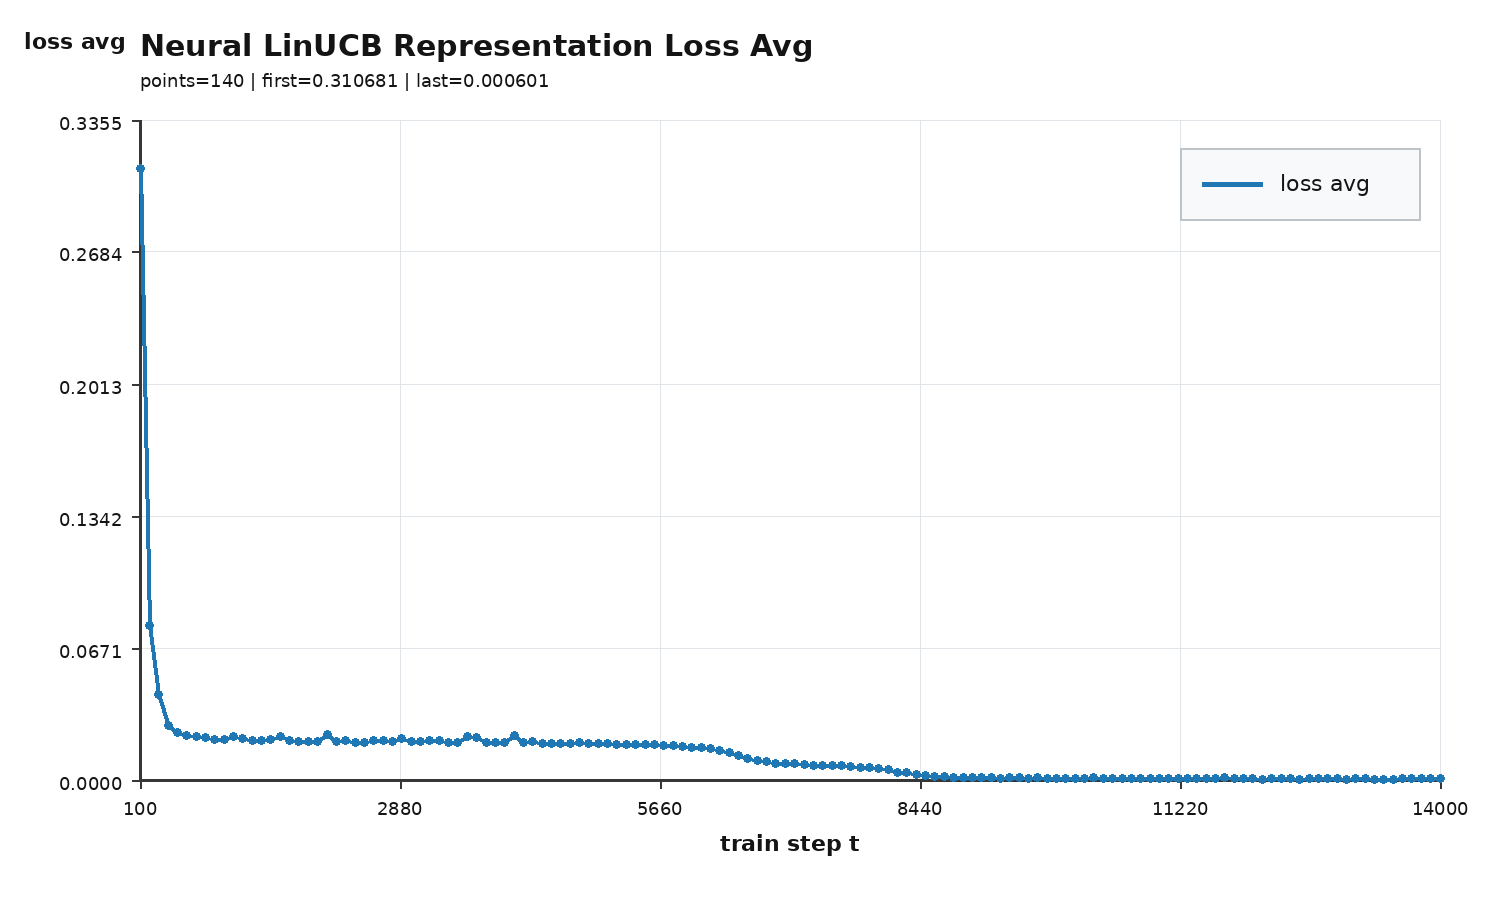

In [3]:
from pathlib import Path
import re

from PIL import Image as PILImage, ImageDraw, ImageFont

try:
    from IPython.display import Image, display
except Exception:
    Image = None
    display = None


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "2cmab2").exists():
            return candidate
    raise RuntimeError("无法自动定位仓库根目录，请手动修改 RUN_DIR")


def load_font(size: int, bold: bool = False):
    candidates = []
    if bold:
        candidates.append(Path("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"))
    candidates.append(Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"))
    for path in candidates:
        if path.exists():
            return ImageFont.truetype(str(path), size=size)
    return ImageFont.load_default()


def render_loss_plot_png(steps: list[int], raw_values: list[float], out_path: Path) -> None:
    width, height = 1500, 900
    left, right, top, bottom = 140, 60, 120, 120
    plot_w = width - left - right
    plot_h = height - top - bottom

    bg = (255, 255, 255)
    axis = (55, 55, 55)
    grid = (225, 228, 232)
    raw_color = (31, 119, 180)
    text = (20, 20, 20)
    legend_bg = (248, 249, 251)
    legend_border = (190, 195, 200)

    img = PILImage.new("RGB", (width, height), bg)
    draw = ImageDraw.Draw(img)

    title_font = load_font(30, bold=True)
    label_font = load_font(22, bold=True)
    tick_font = load_font(18)
    legend_font = load_font(22)
    meta_font = load_font(18)

    x_min, x_max = min(steps), max(steps)
    y_min = 0.0
    y_max = max(raw_values) if raw_values else 1.0
    if y_max <= 0.0:
        y_max = 1.0
    y_max += max(y_max * 0.08, 1e-4)

    def sx(x: int) -> int:
        if x_max == x_min:
            return left + plot_w // 2
        return int(left + (x - x_min) / (x_max - x_min) * plot_w)

    def sy(y: float) -> int:
        if y_max == y_min:
            return top + plot_h // 2
        return int(top + (y_max - y) / (y_max - y_min) * plot_h)

    def measure(text_value: str, font) -> tuple[int, int]:
        bbox = draw.textbbox((0, 0), text_value, font=font)
        return bbox[2] - bbox[0], bbox[3] - bbox[1]

    y_tick_count = 6
    for idx in range(y_tick_count):
        ratio = idx / (y_tick_count - 1)
        y_val = y_max * (1.0 - ratio)
        y_pos = sy(y_val)
        draw.line((left, y_pos, width - right, y_pos), fill=grid, width=1)
        draw.line((left - 8, y_pos, left, y_pos), fill=axis, width=2)
        label = f"{y_val:.4f}"
        tw, th = measure(label, tick_font)
        draw.text((left - 18 - tw, y_pos - th / 2), label, fill=text, font=tick_font)

    x_tick_count = 6
    for idx in range(x_tick_count):
        ratio = idx / (x_tick_count - 1)
        x_val = int(round(x_min + (x_max - x_min) * ratio))
        x_pos = sx(x_val)
        draw.line((x_pos, top, x_pos, height - bottom), fill=grid, width=1)
        draw.line((x_pos, height - bottom, x_pos, height - bottom + 8), fill=axis, width=2)
        label = str(x_val)
        tw, th = measure(label, tick_font)
        draw.text((x_pos - tw / 2, height - bottom + 18), label, fill=text, font=tick_font)

    draw.line((left, top, left, height - bottom), fill=axis, width=3)
    draw.line((left, height - bottom, width - right, height - bottom), fill=axis, width=3)

    raw_points = [(sx(x), sy(y)) for x, y in zip(steps, raw_values)]
    if len(raw_points) >= 2:
        draw.line(raw_points, fill=raw_color, width=4)
    for x_pos, y_pos in raw_points:
        draw.ellipse((x_pos - 4, y_pos - 4, x_pos + 4, y_pos + 4), fill=raw_color)

    draw.text((left, 28), "Neural LinUCB Representation Loss Avg", fill=text, font=title_font)
    summary = f"points={len(steps)} | first={raw_values[0]:.6f} | last={raw_values[-1]:.6f}"
    draw.text((left, 70), summary, fill=text, font=meta_font)

    x_label = "train step t"
    tw, th = measure(x_label, label_font)
    draw.text((left + plot_w / 2 - tw / 2, height - 70), x_label, fill=text, font=label_font)
    draw.text((24, 28), "loss avg", fill=text, font=label_font)

    legend_x0 = width - right - 260
    legend_y0 = top + 28
    legend_x1 = width - right - 20
    legend_y1 = legend_y0 + 72
    draw.rectangle((legend_x0, legend_y0, legend_x1, legend_y1), fill=legend_bg, outline=legend_border, width=2)
    legend_line_y = (legend_y0 + legend_y1) // 2
    draw.line((legend_x0 + 22, legend_line_y, legend_x0 + 82, legend_line_y), fill=raw_color, width=5)
    draw.text((legend_x0 + 100, legend_line_y - 14), "loss avg", fill=text, font=legend_font)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(out_path)


REPO_ROOT = find_repo_root(Path.cwd())
RUN_DIR = REPO_ROOT / "2cmab2/outputs/2026-03-25-18-53-19_neural_linucb"
LOG_PATH = RUN_DIR / "neural_linucb.log"
PNG_PATH = RUN_DIR / "loss_avg_curve.png"

train_pattern = re.compile(r"\|\s*t=(?P<t>\d+)\s*\|\s*TRAIN\s*\|\s*module=representation")
loss_pattern = re.compile(
    r"loss:\s*avg=(?P<avg>[0-9.]+)\s*\|\s*min=(?P<min>[0-9.]+)\s*\|\s*max=(?P<max>[0-9.]+)\s*\|\s*last=(?P<last>[0-9.]+)"
)

records: list[dict[str, float | int]] = []
pending_t: int | None = None

with LOG_PATH.open("r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        train_match = train_pattern.search(line)
        if train_match is not None:
            pending_t = int(train_match.group("t"))
            continue

        loss_match = loss_pattern.search(line)
        if loss_match is not None and pending_t is not None:
            records.append(
                {
                    "t": pending_t,
                    "avg_loss": float(loss_match.group("avg")),
                    "min_loss": float(loss_match.group("min")),
                    "max_loss": float(loss_match.group("max")),
                    "last_loss": float(loss_match.group("last")),
                }
            )
            pending_t = None

if not records:
    raise ValueError(f"没有在日志中解析到 `loss: avg` 记录: {LOG_PATH}")

steps = [int(row["t"]) for row in records]
avg_losses = [float(row["avg_loss"]) for row in records]

render_loss_plot_png(steps, avg_losses, PNG_PATH)

print(f"共解析到 {len(records)} 个 loss 点")
print(f"首个点: t={steps[0]}, avg_loss={avg_losses[0]:.6f}")
print(f"最后点: t={steps[-1]}, avg_loss={avg_losses[-1]:.6f}")
print(f"PNG 已保存到: {PNG_PATH}")
if Image is not None and display is not None:
    display(Image(filename=str(PNG_PATH)))
